# 10 - Architettura completa PWfE: prosodia + Whisper (livello di file) + ECAPA, fusione tardiva end-to-end

Modello completo con i **tre rami addestrati insieme** (end-to-end) su ASVspoof 2019 LA
(train per l'addestramento, dev per validazione e misura).

**Ingressi (tre sorgenti gia' estratte, nessuna ri-estrazione qui):**
- **P - prosodia (notebook 04, `prosody_features`)**, configurazione Praat `standard`, finestre da 200 ms
  senza sovrapposizione, silenzio incluso (finestra senza frame sonori = tutte le feature a 0).
  Variante **D**: le 8 feature piu' le loro differenze con la finestra precedente, quindi `(T_p, 16)`.
  E' l'unico ramo **sequenziale**.
- **Wf - Whisper-base, encoder, ultimo layer (notebook 08), livello di file**: media dei soli frame reali,
  512 valori per file (`whisper_mean_<split>.npz`). Modello **congelato** in fase di estrazione.
- **E - ECAPA-TDNN `speechbrain/spkrec-ecapa-voxceleb` (notebook 08)**, livello di file: 192 valori
  **grezzi**, nessuna normalizzazione L2.

Poiche' Whisper e' usato a livello di file, gli shard di frame del notebook 08 (circa 9 GB per partizione)
**non vengono letti**: il notebook carica pochi MB e parte in pochi secondi.

**Architettura**
```
P : (T_p, 16) -> Conv1D 256 -> Conv1D 128 -> LSTM 100 -> LSTM 50 -> attention -> emb 50 -> BatchNorm
Wf: (512)     -> Linear 128 -> BN -> ReLU -> Dropout -> Linear 50               -> emb 50 -> BatchNorm
E : (192)     -> Linear 128 -> BN -> ReLU -> Dropout -> Linear 50               -> emb 50 -> BatchNorm
concatenazione (150) -> Linear 50 -> ReLU -> Dropout -> Linear 1    (logit bona fide)
```
La spina dorsale sequenziale del ramo P e' la stessa del notebook 06; i rami a livello di file sono quelli
del notebook 09.

**Preprocessing, statistiche calcolate sul solo train:**
- P: clipping ai percentili 0,1-99,9 (sui soli valori validi) e Min-Max, **identico al notebook 06**;
- Wf ed E: standardizzazione per dimensione, **identica al notebook 09**.

**Training:** Adam (lr 0,001), batch 32, BCE pesata (`pos_weight` = spoof/bona fide del train), massimo
40 epoche, `ReduceLROnPlateau` (0,5, pazienza 3) sulla loss del dev, early stopping sulla **eer del dev**
(pazienza 10), checkpoint con la loss del dev piu' bassa. **Un solo seme (0)**.

**Metriche:** EER e curva DET con le funzioni **ufficiali ASVspoof 2021** (`eval_metrics.py`, stesso file e
stesso SHA256 dei notebook 06 e 09). AUC con `roc_auc_score` di scikit-learn, dichiarata come metrica
**non ASVspoof**.



In [1]:

import os, re, json, time, copy, math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.metrics import roc_auc_score
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence, PackedSequence

# Cartelle di ingresso. Lasciando None vengono cercate sotto /kaggle/input.
TRAIN_DIR    = "/kaggle/input/datasets/angelopaldino/outputtrain-feature-noft/ptm_features_train"
DEV_DIR      = "/kaggle/input/datasets/angelopaldino/devroot/root"
PROSODY_DIR  = "/kaggle/input/datasets/angelopaldino/prosody-features/prosody_features"   

EXTERNAL_SCORES = {}

INPUT_ROOT = Path(os.environ.get("INPUT_ROOT", "/kaggle/input"))
OUT_DIR = Path(os.environ.get("OUT_DIR", "/kaggle/working/full_pwfe"))
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Rami: P = prosodia (sequenza), W = Whisper livello di frame, Wf = Whisper livello di file, E = ECAPA livello di file
VARIANTS = ["PWfE"]
SEEDS = [0]
MAX_EPOCHS = int(os.environ.get("MAX_EPOCHS", 40))
PATIENCE = int(os.environ.get("PATIENCE", 10))
LR_FACTOR, LR_PATIENCE = 0.5, 3
BATCH_SIZE, LR, DROPOUT = 32, 1e-3, 0.2
EVAL_BATCH = 64
N_BOOT = 1000
SAVE_ATTENTION = False               # pesi di attention del ramo prosodico sul dev (analisi del silenzio)
D_WHISPER, D_ECAPA = 512, 192
EMB_DIM = 50
EXPECTED_ROWS = {"train": 25380, "dev": 24844}

PROSODY_CONFIG = "standard"          # configurazione Praat del notebook 04
PROSODY_VARIANT = "D"                # 8 feature + delta (scelta nel notebook 06)
N_BLOCKS = {"A": 1, "D": 2, "E": 3}
CLIP_PCT = (0.1, 99.9)               # percentili del clipping, identici al notebook 06

def parse_variant(v):
    # "PWfE" -> ["P", "Wf", "E"]; "PWE" -> ["P", "W", "E"]. Wf va cercato prima di W.
    toks = re.findall(r"Wf|P|W|E", v)
    assert "".join(toks) == v and len(set(toks)) == len(toks), f"Variante non valida: {v}"
    return toks

BRANCHES = {v: parse_variant(v) for v in VARIANTS}
NEED_FRAMES = any("W" in b for b in BRANCHES.values())   # gli shard si leggono solo per il ramo frame-level

# float32 = dati esatti. Con il solo livello di file l'ingombro e' di pochi MB; con il ramo frame-level
# (variante che contiene "W") servono circa 9 GB per partizione.
STORE_DTYPE = np.float32

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if DEVICE == "cuda":
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
print("device:", DEVICE, "| torch", torch.__version__, "| rami:", BRANCHES,
      "| shard di frame da leggere:", NEED_FRAMES)

device: cuda | torch 2.10.0+cu128 | rami: {'PWfE': ['P', 'Wf', 'E']} | shard di frame da leggere: False


In [2]:

import sys, hashlib, importlib.util, urllib.request

EVAL_METRICS_PATH = None
EVAL_METRICS_URL = "https://raw.githubusercontent.com/asvspoof-challenge/2021/main/eval-package/eval_metrics.py"

if EVAL_METRICS_PATH is None:
    EVAL_METRICS_PATH = OUT_DIR / "eval_metrics.py"
    if not EVAL_METRICS_PATH.exists():
        urllib.request.urlretrieve(EVAL_METRICS_URL, EVAL_METRICS_PATH)
EVAL_METRICS_PATH = Path(EVAL_METRICS_PATH)
spec = importlib.util.spec_from_file_location("asvspoof_eval_metrics", EVAL_METRICS_PATH)
asv_metrics = importlib.util.module_from_spec(spec); spec.loader.exec_module(asv_metrics)
EVAL_METRICS_SHA256 = hashlib.sha256(EVAL_METRICS_PATH.read_bytes()).hexdigest()
print("eval_metrics.py:", EVAL_METRICS_PATH, "| sha256", EVAL_METRICS_SHA256[:16], "...")

def compute_eer(y, s):
    # EER ufficiale ASVspoof: y = 1 bona fide, 0 spoof; s = punteggio (alto = bona fide)
    y, s = np.asarray(y), np.asarray(s, dtype=np.float64)
    eer, _ = asv_metrics.compute_eer(s[y == 1], s[y == 0])
    return float(eer)

# controllo rapido: punteggi perfettamente separati -> EER 0; punteggi invertiti -> EER 1
assert compute_eer([1, 1, 0, 0], [2.0, 3.0, 0.0, 1.0]) == 0.0
assert compute_eer([1, 1, 0, 0], [0.0, 1.0, 2.0, 3.0]) == 1.0

eval_metrics.py: /kaggle/working/full_pwfe/eval_metrics.py | sha256 70c5d2fe8fab6654 ...


In [3]:

def find_dir(given, needed):
    if given:
        return Path(given)
    hits = []
    for dirpath, dirnames, filenames in os.walk(INPUT_ROOT):
        dirnames[:] = [d for d in dirnames if d != "flac"]
        if all(f in filenames for f in needed):
            hits.append(Path(dirpath))
    assert len(hits) == 1, f"Cartella con {needed} non trovata o ambigua: {hits}. Imposta il percorso a mano."
    return hits[0]

def load_ptm(split, given):
    # Whisper (livello di file, e frame solo se serve) + ECAPA (livello di file), dal notebook 08
    d = find_dir(given, [f"index_{split}.csv", f"meta_{split}.json"])
    idx = pd.read_csv(d / f"index_{split}.csv")
    meta = json.loads((d / f"meta_{split}.json").read_text())
    assert len(idx) == EXPECTED_ROWS[split], (split, len(idx), EXPECTED_ROWS[split])
    utt_ref = idx["utt_id"].to_numpy()

    lens = idx["n_frames"].to_numpy().astype(np.int64)
    offsets = np.concatenate([[0], np.cumsum(lens)]).astype(np.int64)
    X = None
    if NEED_FRAMES:
        n_frames_tot = int(offsets[-1])
        gb = n_frames_tot * D_WHISPER * np.dtype(STORE_DTYPE).itemsize / 1e9
        print(f"{split} (Whisper frame): {n_frames_tot:,} frame | {gb:.2f} GB in memoria")
        X = np.empty((n_frames_tot, D_WHISPER), dtype=STORE_DTYPE)
        shards = sorted(d.glob(f"whisper_{split}_shard*.npz"))
        assert len(shards) == meta["n_shards"], (len(shards), meta["n_shards"])
        utt, pos, nonfinite = [], 0, []
        for p in shards:
            z = np.load(p, allow_pickle=True)
            x = z["X"]
            if not np.isfinite(x).all():
                nonfinite.append(p.name)
            X[pos:pos + len(x)] = x
            pos += len(x)
            utt.append(z["utt_id"])
            del z, x
        assert pos == n_frames_tot, (pos, n_frames_tot)
        assert (np.concatenate(utt) == utt_ref).all(), "Ordine degli utt_id degli shard diverso da index_<split>.csv"
        assert not nonfinite, nonfinite

    z = np.load(d / f"whisper_mean_{split}.npz", allow_pickle=True)
    assert (z["utt_id"] == utt_ref).all(), "Ordine degli utt_id di whisper_mean diverso da index_<split>.csv"
    wmean = z["whisper_mean"].astype(np.float32)
    assert wmean.shape == (len(idx), D_WHISPER), wmean.shape
    assert np.isfinite(wmean).all()

    z = np.load(d / f"ecapa_{split}.npz", allow_pickle=True)
    assert (z["utt_id"] == utt_ref).all(), "Ordine degli utt_id di ecapa diverso da index_<split>.csv"
    ecapa = z["ecapa"].astype(np.float32)
    assert ecapa.shape == (len(idx), D_ECAPA), ecapa.shape
    assert np.isfinite(ecapa).all()

    print(f"{split} (livello di file): {len(idx)} file | whisper_mean {wmean.shape} | ecapa {ecapa.shape} | cartella {d}")
    return {"dir": str(d), "meta": meta, "index": idx, "Xw": X, "off_w": offsets, "len_w": lens,
            "wmean": wmean, "ecapa": ecapa, "y": idx["y_bonafide"].to_numpy().astype(np.float32),
            "attack": idx["attack"].to_numpy(), "utt": utt_ref}

PROSODY_ROOT = find_dir(PROSODY_DIR, ["index.csv", "meta.json", f"{PROSODY_CONFIG}_train.npz"])
meta_pros = json.loads((PROSODY_ROOT / "meta.json").read_text())
BASE_FEATURES = meta_pros["features"]
print("Prosodia:", PROSODY_ROOT, "| finestra", meta_pros["window_s"], "s | feature:", BASE_FEATURES)

def load_prosody(split, utt_ref):
    z = np.load(PROSODY_ROOT / f"{PROSODY_CONFIG}_{split}.npz", allow_pickle=True)
    utt, X, off = z["utt_id"], z["X"].astype(np.float32), z["offsets"].astype(np.int64)
    assert len(utt) == EXPECTED_ROWS[split], (split, len(utt), EXPECTED_ROWS[split])
    assert X.shape[1] == len(BASE_FEATURES), (X.shape, len(BASE_FEATURES))
    assert int(off[-1]) == len(X), (int(off[-1]), len(X))
    assert np.isfinite(X).all()
    assert (utt == utt_ref).all(), "Ordine degli utt_id della prosodia diverso da index_<split>.csv"
    print(f"{split} (prosodia): {len(utt)} file | {len(X):,} finestre | {X.nbytes / 1e6:.1f} MB")
    return [X[off[i]:off[i + 1]] for i in range(len(utt))]

DATA = {}
for s in ["train", "dev"]:
    DATA[s] = load_ptm(s, TRAIN_DIR if s == "train" else DEV_DIR)
    DATA[s]["seqs_p"] = load_prosody(s, DATA[s]["utt"])

for s, sp in DATA.items():
    Lp = np.array([len(x) for x in sp["seqs_p"]])
    print(f"{s}: bona fide {int(sp['y'].sum())} | spoof {int((1 - sp['y']).sum())} | "
          f"finestre prosodia min {Lp.min()}, mediana {np.median(Lp):.0f}, max {Lp.max()}")
print("Norma L2 media degli embedding ECAPA grezzi (train): %.3f" % np.linalg.norm(DATA["train"]["ecapa"], axis=1).mean())

Prosodia: /kaggle/input/datasets/angelopaldino/prosody-features/prosody_features | finestra 0.2 s | feature: ['f0_mean', 'f0_std', 'jitter_local', 'shimmer_local', 'hnr_mean', 'hnr_std', 'intensity_mean', 'intensity_std']
train (livello di file): 25380 file | whisper_mean (25380, 512) | ecapa (25380, 192) | cartella /kaggle/input/datasets/angelopaldino/outputtrain-feature-noft/ptm_features_train
train (prosodia): 25380 file | 434,766 finestre | 13.9 MB
dev (livello di file): 24844 file | whisper_mean (24844, 512) | ecapa (24844, 192) | cartella /kaggle/input/datasets/angelopaldino/devroot/root
dev (prosodia): 24844 file | 432,089 finestre | 13.8 MB
train: bona fide 2580 | spoof 22800 | finestre prosodia min 3, mediana 16, max 66
dev: bona fide 2548 | spoof 22296 | finestre prosodia min 3, mediana 16, max 58
Norma L2 media degli embedding ECAPA grezzi (train): 330.284


In [4]:

def voiced_mask(x):
    return np.abs(x).sum(1) > 0

def dynamic_features(x):
    # (delta, delta_valido, deltadelta, deltadelta_valido); 0 se una delle finestre coinvolte e' senza voce
    v = voiced_mask(x)
    n = len(x)
    d_ok = np.zeros(n, dtype=bool)
    d_ok[1:] = v[1:] & v[:-1]
    d = np.zeros_like(x)
    d[d_ok] = x[d_ok] - x[np.where(d_ok)[0] - 1]
    dd_ok = np.zeros(n, dtype=bool)
    dd_ok[1:] = d_ok[1:] & d_ok[:-1]
    dd = np.zeros_like(x)
    dd[dd_ok] = d[dd_ok] - d[np.where(dd_ok)[0] - 1]
    return d, d_ok, dd, dd_ok

# Verifica delle definizioni su un esempio (una sola feature, silenzio in posizione 3)
_x = np.array([[180.], [195.], [170.], [0.], [175.], [190.], [185.]], dtype=np.float32)
_d, _, _dd, _ = dynamic_features(_x)
assert _d[:, 0].tolist() == [0, 15, -25, 0, 0, 15, -5], _d[:, 0]
assert _dd[:, 0].tolist() == [0, 0, -40, 0, 0, 0, -20], _dd[:, 0]

def build_variant(seqs, variant=PROSODY_VARIANT):
    out = []
    for x in seqs:
        d, _, dd, _ = dynamic_features(x)
        out.append(np.concatenate([x, d, dd][:N_BLOCKS[variant]], axis=1))
    return out

def feature_names(variant=PROSODY_VARIANT):
    blocks = [BASE_FEATURES, [f"d_{f}" for f in BASE_FEATURES], [f"dd_{f}" for f in BASE_FEATURES]]
    return sum(blocks[:N_BLOCKS[variant]], [])

def row_validity(seqs_base, variant=PROSODY_VARIANT):
    # Per ogni finestra: quali canali contengono un valore valido (serve per i percentili del clipping)
    out = []
    for x in seqs_base:
        _, d_ok, _, dd_ok = dynamic_features(x)
        masks = [voiced_mask(x), d_ok, dd_ok][:N_BLOCKS[variant]]
        out.append(np.concatenate([np.repeat(m[:, None], x.shape[1], axis=1) for m in masks], axis=1))
    return out

def fit_prosody_preproc(train_seqs, train_base):
    allw = np.concatenate(train_seqs)
    valid = np.concatenate(row_validity(train_base))
    clip_lo = np.array([np.percentile(allw[valid[:, j], j], CLIP_PCT[0]) for j in range(allw.shape[1])])
    clip_hi = np.array([np.percentile(allw[valid[:, j], j], CLIP_PCT[1]) for j in range(allw.shape[1])])
    clipped = np.where(valid, np.clip(allw, clip_lo, clip_hi), allw)
    lo, hi = clipped.min(0), clipped.max(0)
    rng_ = np.where(hi - lo > 0, hi - lo, 1.0)
    return {k: v.astype(np.float32) for k, v in
            {"clip_lo": clip_lo, "clip_hi": clip_hi, "minmax_lo": lo, "minmax_range": rng_}.items()}

def transform_prosody(seqs, base_seqs, pp):
    valid = row_validity(base_seqs)
    return [(np.where(m, np.clip(x, pp["clip_lo"], pp["clip_hi"]), x) - pp["minmax_lo"]) / pp["minmax_range"]
            for x, m in zip(seqs, valid)]

def pack_seqs(seqs):
    lens = np.array([len(x) for x in seqs], dtype=np.int64)
    off = np.concatenate([[0], np.cumsum(lens)]).astype(np.int64)
    return np.concatenate(seqs).astype(np.float32), off, lens

def fit_standardizer(X, chunk=100_000):
    s = np.zeros(X.shape[1], dtype=np.float64)
    ss = np.zeros(X.shape[1], dtype=np.float64)
    n = 0
    for i in range(0, len(X), chunk):
        b = X[i:i + chunk].astype(np.float64)
        s += b.sum(0); ss += (b * b).sum(0); n += len(b)
    mean = s / n
    var = np.maximum(ss / n - mean * mean, 0.0)
    std = np.sqrt(var)
    std[std < 1e-6] = 1.0           # dimensioni costanti: nessun riscalamento
    return mean.astype(np.float32), std.astype(np.float32), n

def apply_standardizer(X, mean, std, chunk=100_000):
    for i in range(0, len(X), chunk):
        X[i:i + chunk] = ((X[i:i + chunk].astype(np.float32) - mean) / std).astype(X.dtype)

t0 = time.perf_counter()

# --- prosodia -------------------------------------------------------------
BASE_DEV_SEQS = DATA["dev"]["seqs_p"]                       # grezze, servono per la diagnostica del silenzio
built = {s: build_variant(DATA[s]["seqs_p"]) for s in ["train", "dev"]}
PP = fit_prosody_preproc(built["train"], DATA["train"]["seqs_p"])
for s in ["train", "dev"]:
    tr = transform_prosody(built[s], DATA[s]["seqs_p"], PP)
    DATA[s]["Xp"], DATA[s]["off_p"], DATA[s]["len_p"] = pack_seqs(tr)
    del tr
del built
D_PROSODY = DATA["train"]["Xp"].shape[1]
(OUT_DIR / "preproc_prosody.json").write_text(json.dumps(
    {"config": PROSODY_CONFIG, "variant": PROSODY_VARIANT, "features": feature_names(),
     "clip_pct": list(CLIP_PCT), "fit_on": "solo train",
     **{k: a.tolist() for k, a in PP.items()}}, indent=1))

# --- Whisper (livello di file) ed ECAPA ------------------------------------
WM_MEAN, WM_STD, _ = fit_standardizer(DATA["train"]["wmean"])
E_MEAN, E_STD, _ = fit_standardizer(DATA["train"]["ecapa"])
for s in ["train", "dev"]:
    DATA[s]["wmean"] = (DATA[s]["wmean"] - WM_MEAN) / WM_STD
    DATA[s]["ecapa"] = (DATA[s]["ecapa"] - E_MEAN) / E_STD
stats = {"whisper_file_mean": WM_MEAN.tolist(), "whisper_file_std": WM_STD.tolist(),
         "ecapa_mean": E_MEAN.tolist(), "ecapa_std": E_STD.tolist(), "fit_on": "solo train"}

# --- Whisper (livello di frame), solo se una variante lo usa ---------------
if NEED_FRAMES:
    W_MEAN, W_STD, n_used = fit_standardizer(DATA["train"]["Xw"])
    for s in ["train", "dev"]:
        apply_standardizer(DATA[s]["Xw"], W_MEAN, W_STD)
    stats.update({"whisper_frame_mean": W_MEAN.tolist(), "whisper_frame_std": W_STD.tolist(),
                  "frames_train_used": int(n_used)})
(OUT_DIR / "standardizer.json").write_text(json.dumps(stats, indent=1))

print(f"Preprocessing completato in {time.perf_counter() - t0:.0f} s")
print(f"Prosodia variante {PROSODY_VARIANT}: {D_PROSODY} canali | "
      f"range dopo scaling [{DATA['train']['Xp'].min():.2f}, {DATA['train']['Xp'].max():.2f}]")
print("Whisper livello di file, train dopo standardizzazione: media %.4f | dev.std %.4f" %
      (DATA["train"]["wmean"].mean(), DATA["train"]["wmean"].std()))
print("ECAPA train dopo standardizzazione: media %.4f | dev.std %.4f" %
      (DATA["train"]["ecapa"].mean(), DATA["train"]["ecapa"].std()))
if NEED_FRAMES:
    print("Whisper livello di frame, train dopo standardizzazione: media %.4f | dev.std %.4f" %
          (DATA["train"]["Xw"][:200000].mean(), DATA["train"]["Xw"][:200000].std()))

Preprocessing completato in 7 s
Prosodia variante D: 16 canali | range dopo scaling [0.00, 1.00]
Whisper livello di file, train dopo standardizzazione: media 0.0000 | dev.std 1.0000
ECAPA train dopo standardizzazione: media 0.0000 | dev.std 1.0000


In [5]:
def _pad_batch(X, off, lens, idx, n_ch):
    L = lens[idx]
    B = torch.zeros(len(idx), int(L.max()), n_ch)
    for k, i in enumerate(idx):
        n = int(lens[i])
        B[k, :n] = torch.from_numpy(X[off[i]:off[i] + n])
    return B, torch.from_numpy(L)

def batch_inputs(sp, idx):
    Bp, Lp = _pad_batch(sp["Xp"], sp["off_p"], sp["len_p"], idx, D_PROSODY)
    Bw, Lw = (None, torch.from_numpy(sp["len_w"][idx]))
    if NEED_FRAMES:
        Bw, Lw = _pad_batch(sp["Xw"], sp["off_w"], sp["len_w"], idx, D_WHISPER)
    Bm = torch.from_numpy(sp["wmean"][idx])
    Be = torch.from_numpy(sp["ecapa"][idx])
    return Bp, Lp, Bw, Lw, Bm, Be

_bp, _lp, _bw, _lw, _bm, _be = batch_inputs(DATA["dev"], np.array([0, 1, 2]))
print("Esempio di batch | prosodia", tuple(_bp.shape), tuple(_lp.tolist()),
      "| whisper frame", tuple(_bw.shape) if _bw is not None else "non caricati",
      "| whisper file", tuple(_bm.shape), "| ecapa", tuple(_be.shape))
del _bp, _lp, _bw, _lw, _bm, _be

Esempio di batch | prosodia (3, 27, 16) (27, 16, 16) | whisper frame non caricati | whisper file (3, 512) | ecapa (3, 192)


In [6]:

def masked_bn(x, mask, bn):
    # BatchNorm sui soli passi reali. x: (B, T, C), mask: (B, T)
    y = torch.zeros_like(x)
    y[mask] = bn(x[mask])
    return y

def map_packed(p, fn):
    return PackedSequence(fn(p.data), p.batch_sizes, p.sorted_indices, p.unsorted_indices)

class SeqBranch(nn.Module):
    # 1D-CNN (senza pooling) -> LSTM -> attention con maschera. Uscita: embedding da 50
    def __init__(self, n_in, p=DROPOUT):
        super().__init__()
        self.conv1, self.bn_c1 = nn.Conv1d(n_in, 256, kernel_size=3, padding=1), nn.BatchNorm1d(256)
        self.conv2, self.bn_c2 = nn.Conv1d(256, 128, kernel_size=3, padding=1), nn.BatchNorm1d(128)
        self.drop = nn.Dropout(p)
        self.lstm1, self.bn_l1 = nn.LSTM(128, 100, batch_first=True), nn.BatchNorm1d(100)
        self.lstm2, self.bn_l2 = nn.LSTM(100, 50, batch_first=True), nn.BatchNorm1d(50)
        self.att_w, self.att_v = nn.Linear(50, 50), nn.Linear(50, 1, bias=False)
        self.out_dim = EMB_DIM

    def conv_block(self, h, conv, bn, mask):
        h = conv(h.transpose(1, 2)).transpose(1, 2)
        h = F.relu(masked_bn(h, mask, bn))
        return self.drop(h) * mask.unsqueeze(-1)

    def forward(self, x, lengths):
        T = x.shape[1]
        mask = torch.arange(T, device=x.device)[None, :] < lengths.to(x.device)[:, None]
        h = self.conv_block(x, self.conv1, self.bn_c1, mask)
        h = self.conv_block(h, self.conv2, self.bn_c2, mask)
        p = pack_padded_sequence(h, lengths.cpu(), batch_first=True, enforce_sorted=False)
        p, _ = self.lstm1(p)
        p = map_packed(map_packed(p, self.bn_l1), self.drop)
        p, _ = self.lstm2(p)
        p = map_packed(p, self.bn_l2)
        H, _ = pad_packed_sequence(p, batch_first=True, total_length=T)
        e = self.att_v(torch.tanh(self.att_w(H))).squeeze(-1)
        a = torch.softmax(e.masked_fill(~mask, float("-inf")), dim=1)
        return (a.unsqueeze(-1) * H).sum(1), a

class FileBranch(nn.Module):
    # MLP su un vettore a livello di file (512 per whisper_mean, 192 per ECAPA). Uscita: embedding da 50
    def __init__(self, n_in, p=DROPOUT):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(n_in, 128), nn.BatchNorm1d(128), nn.ReLU(),
                                 nn.Dropout(p), nn.Linear(128, EMB_DIM))
        self.out_dim = EMB_DIM

    def forward(self, x):
        return self.net(x)

class Detector(nn.Module):
    # variant e' una stringa sui token P (prosodia), W (Whisper frame), Wf (Whisper file), E (ECAPA file)
    def __init__(self, variant, p=DROPOUT):
        super().__init__()
        self.variant = variant
        self.toks = parse_variant(variant)
        self.use_p, self.use_w = "P" in self.toks, "W" in self.toks
        self.use_wf, self.use_e = "Wf" in self.toks, "E" in self.toks
        d = 0
        if self.use_p:
            self.pb = SeqBranch(D_PROSODY, p); d += EMB_DIM
        if self.use_w:
            self.wb = SeqBranch(D_WHISPER, p); d += EMB_DIM
        if self.use_wf:
            self.wfb = FileBranch(D_WHISPER, p); d += EMB_DIM
        if self.use_e:
            self.eb = FileBranch(D_ECAPA, p); d += EMB_DIM
        # BatchNorm solo quando i rami sono piu' di uno, per rendere confrontabili le scale
        self.fuse = d > EMB_DIM
        if self.fuse:
            self.bn_fuse = nn.ModuleList([nn.BatchNorm1d(EMB_DIM) for _ in range(d // EMB_DIM)])
        self.head = nn.Sequential(nn.Linear(d, 50), nn.ReLU(), nn.Dropout(p), nn.Linear(50, 1))

    def forward(self, xp, lp, xw, lw, xm, xe):
        parts, att = [], {}
        if self.use_p:
            zp, att["P"] = self.pb(xp, lp); parts.append(zp)
        if self.use_w:
            zw, att["W"] = self.wb(xw, lw); parts.append(zw)
        if self.use_wf:
            parts.append(self.wfb(xm))
        if self.use_e:
            parts.append(self.eb(xe))
        if self.fuse:
            parts = [bn(z) for bn, z in zip(self.bn_fuse, parts)]
        z = torch.cat(parts, dim=1) if len(parts) > 1 else parts[0]
        return self.head(z).squeeze(-1), att

for v in VARIANTS:
    _m = Detector(v)
    tot = sum(p.numel() for p in _m.parameters())
    per_branch = {n: sum(p.numel() for p in getattr(_m, n).parameters())
                  for n in ["pb", "wb", "wfb", "eb"] if hasattr(_m, n)}
    print(f"Variante {v}: {tot:,} parametri | per ramo {per_branch}")
del _m

Variante PWfE: 348,725 parametri | per ramo {'pb': 237044, 'wfb': 72370, 'eb': 31410}


In [7]:

Y_TR, Y_DEV, ATTACK_DEV = DATA["train"]["y"], DATA["dev"]["y"], DATA["dev"]["attack"]
POS_W = float((Y_TR == 0).sum() / (Y_TR == 1).sum())
print("pos_weight (train):", round(POS_W, 4))

def _to_dev(t):
    return t.to(DEVICE) if t is not None else None

def evaluate(model, sp, y, loss_fn, bs=EVAL_BATCH, want_att=False):
    model.eval()
    scores, att_p, tot = [], [], 0.0
    with torch.no_grad():
        for k in range(0, len(y), bs):
            idx = np.arange(k, min(k + bs, len(y)))
            Bp, Lp, Bw, Lw, Bm, Be = batch_inputs(sp, idx)
            out, att = model(_to_dev(Bp), Lp, _to_dev(Bw), Lw, _to_dev(Bm), _to_dev(Be))
            tot += loss_fn(out, torch.from_numpy(y[idx]).to(DEVICE)).item() * len(idx)
            scores.append(out.cpu().numpy())
            if want_att and "P" in att:
                a = att["P"]
                att_p += [a[i, :int(Lp[i])].cpu().numpy() for i in range(len(idx))]
    return tot / len(y), np.concatenate(scores), att_p

def train_run(variant, seed):
    torch.manual_seed(seed); np.random.seed(seed)
    model = Detector(variant).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    # scheduler ed early stopping sull'EER del dev (metrica da minimizzare), non sulla loss
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=LR_FACTOR, patience=LR_PATIENCE)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(POS_W, device=DEVICE))
    ytr_t = torch.from_numpy(Y_TR)
    g = np.random.default_rng(seed)
    best = {"eer": np.inf, "loss": np.inf, "epoch": 0, "state": None}
    hist, bad = [], 0
    for ep in range(1, MAX_EPOCHS + 1):
        model.train(); tr_loss, n = 0.0, 0
        perm = g.permutation(len(Y_TR))
        for k in range(0, len(perm), BATCH_SIZE):
            b = perm[k:k + BATCH_SIZE]
            if len(b) < 2:
                continue
            Bp, Lp, Bw, Lw, Bm, Be = batch_inputs(DATA["train"], b)
            out, _ = model(_to_dev(Bp), Lp, _to_dev(Bw), Lw, _to_dev(Bm), _to_dev(Be))
            loss = loss_fn(out, ytr_t[b].to(DEVICE))
            opt.zero_grad(); loss.backward(); opt.step()
            tr_loss += loss.item() * len(b); n += len(b)
        dv_loss, dv_scores, _ = evaluate(model, DATA["dev"], Y_DEV, loss_fn)
        dv_eer = compute_eer(Y_DEV, dv_scores)
        hist.append({"variant": variant, "seed": seed, "epoch": ep, "lr": opt.param_groups[0]["lr"],
                     "train_loss": tr_loss / n, "dev_loss": dv_loss,
                     "dev_eer": dv_eer, "dev_auc": roc_auc_score(Y_DEV, dv_scores)})
        print(f"  epoca {ep}: train {hist[-1]['train_loss']:.4f} | loss dev {dv_loss:.4f} | "
              f"EER dev {100 * dv_eer:.2f}%", flush=True)
        sched.step(dv_eer)                                  # lo scheduler segue l'EER, non la loss
        if dv_eer < best["eer"]:
            best = {"eer": dv_eer, "loss": dv_loss, "epoch": ep,
                    "state": copy.deepcopy(model.state_dict())}; bad = 0
        else:
            bad += 1
            if bad >= PATIENCE:
                break
    model.load_state_dict(best["state"])
    _, scores, att = evaluate(model, DATA["dev"], Y_DEV, loss_fn, want_att=SAVE_ATTENTION)
    return model, scores, att, hist, best["epoch"], ep

RES, HIST = OUT_DIR / "results.csv", OUT_DIR / "history.csv"
rows = pd.read_csv(RES).to_dict("records") if RES.exists() else []
SCORES = {}
t_all = time.perf_counter()
for v in VARIANTS:
    for seed in SEEDS:
        tag = f"{v}_seed{seed}"
        f_sc, f_model = OUT_DIR / f"scores_{tag}.npy", OUT_DIR / f"model_{tag}.pt"
        if f_sc.exists() and f_model.exists() and any(r["variant"] == v and r["seed"] == seed for r in rows):
            SCORES[(v, seed)] = np.load(f_sc)
            print(f"{v} seed {seed}: gia' presente, saltato")
            continue
        t0 = time.perf_counter()
        print(f"{v} seed {seed}: inizio")
        model, scores, att, hist, best_ep, last_ep = train_run(v, seed)
        torch.save(model.state_dict(), f_model)
        np.save(f_sc, scores); SCORES[(v, seed)] = scores
        if SAVE_ATTENTION and att:
            a = np.empty(len(att), dtype=object); a[:] = att
            np.savez_compressed(OUT_DIR / f"attention_P_{tag}.npz", attention=a, utt_id=DATA["dev"]["utt"])
        pd.DataFrame(hist).to_csv(HIST, mode="a", index=False, header=not HIST.exists())
        # per confronto con il criterio precedente: quale epoca avrebbe scelto la loss del dev minima
        r_loss = min(hist, key=lambda x: x["dev_loss"])
        rows = [r for r in rows if not (r["variant"] == v and r["seed"] == seed)]
        rows.append({"variant": v, "seed": seed, "eer_dev": compute_eer(Y_DEV, scores),
                     "auc_dev": roc_auc_score(Y_DEV, scores),
                     "best_epoch": best_ep, "last_epoch": last_ep,
                     "epoch_min_loss": r_loss["epoch"], "eer_at_min_loss": r_loss["dev_eer"],
                     "minutes": (time.perf_counter() - t0) / 60})
        pd.DataFrame(rows).to_csv(RES, index=False)
        r = rows[-1]
        print(f"{v} seed {seed}: EER dev {100 * r['eer_dev']:.2f}% | AUC {r['auc_dev']:.4f} | "
              f"epoca migliore (EER) {best_ep}, fermato a {last_ep} | "
              f"con il criterio della loss sarebbe stata l'epoca {r['epoch_min_loss']} "
              f"(EER {100 * r['eer_at_min_loss']:.2f}%) | {r['minutes']:.1f} min")
print(f"Totale: {(time.perf_counter() - t_all) / 60:.1f} min")
res = pd.DataFrame(rows).sort_values(["variant", "seed"])
res.assign(eer_dev=(100 * res["eer_dev"]).round(2), auc_dev=res["auc_dev"].round(4), minutes=res["minutes"].round(1))

pos_weight (train): 8.8372
PWfE seed 0: inizio
  epoca 1: train 0.0923 | loss dev 0.5063 | EER dev 1.96%
  epoca 2: train 0.0274 | loss dev 0.3160 | EER dev 1.29%
  epoca 3: train 0.0289 | loss dev 0.2099 | EER dev 1.42%
  epoca 4: train 0.0142 | loss dev 0.6333 | EER dev 1.96%
  epoca 5: train 0.0174 | loss dev 0.6160 | EER dev 1.81%
  epoca 6: train 0.0130 | loss dev 0.3888 | EER dev 1.73%
  epoca 7: train 0.0083 | loss dev 0.5290 | EER dev 1.84%
  epoca 8: train 0.0037 | loss dev 0.5400 | EER dev 1.85%
  epoca 9: train 0.0039 | loss dev 0.3736 | EER dev 1.41%
  epoca 10: train 0.0188 | loss dev 1.6881 | EER dev 3.14%
  epoca 11: train 0.0059 | loss dev 0.4655 | EER dev 1.92%
  epoca 12: train 0.0052 | loss dev 0.5723 | EER dev 1.57%
PWfE seed 0: EER dev 1.29% | AUC 0.9991 | epoca migliore (EER) 2, fermato a 12 | con il criterio della loss sarebbe stata l'epoca 3 (EER 1.42%) | 3.5 min
Totale: 3.5 min


,variant,seed,eer_dev,auc_dev,best_epoch,last_epoch,epoch_min_loss,eer_at_min_loss,minutes
0,PWfE,0,1.29,0.9991,2,12,3,0.014173,3.5


In [8]:

def paired_bootstrap(s_a, s_b, n_boot=N_BOOT, seed=0):
    g = np.random.default_rng(seed)
    ib, is_ = np.where(Y_DEV == 1)[0], np.where(Y_DEV == 0)[0]
    d = []
    for _ in range(n_boot):
        ii = np.concatenate([g.choice(ib, len(ib)), g.choice(is_, len(is_))])
        d.append(compute_eer(Y_DEV[ii], s_a[ii]) - compute_eer(Y_DEV[ii], s_b[ii]))
    return np.percentile(100 * np.array(d), [2.5, 97.5])

summary = res.groupby("variant").agg(eer_mean=("eer_dev", "mean"), eer_std=("eer_dev", "std"),
                                     auc_mean=("auc_dev", "mean"), auc_std=("auc_dev", "std"),
                                     best_epoch_mean=("best_epoch", "mean"), last_epoch_mean=("last_epoch", "mean"),
                                     eer_at_min_loss_mean=("eer_at_min_loss", "mean"),
                                     minutes_mean=("minutes", "mean"))
summary["eer_at_min_loss_mean"] *= 100
summary[["eer_mean", "eer_std"]] *= 100
avg = {v: np.mean([SCORES[(v, s)] for s in SEEDS], axis=0) for v in VARIANTS}
summary["eer_score_medio"] = [100 * compute_eer(Y_DEV, avg[v]) for v in summary.index]
summary["auc_score_medio"] = [roc_auc_score(Y_DEV, avg[v]) for v in summary.index]
display(summary.round({"eer_mean": 2, "eer_std": 2, "auc_mean": 4, "auc_std": 4, "best_epoch_mean": 1,
                       "last_epoch_mean": 1, "eer_at_min_loss_mean": 2, "minutes_mean": 1,
                       "eer_score_medio": 2, "auc_score_medio": 4}))
print("eer_at_min_loss_mean = EER che si sarebbe ottenuto con il criterio del notebook 06 "
      "(checkpoint alla loss dev minima); riportato solo per documentare lo scostamento.")

per_seed = res.pivot(index="seed", columns="variant", values="eer_dev") * 100
display(per_seed.round(2))

cmp_rows = []
for name, path in EXTERNAL_SCORES.items():
    p = Path(path)
    if not p.exists():
        print(f"Punteggi esterni '{name}' non trovati in {p}: confronto saltato")
        continue
    s_ext = np.load(p)
    assert len(s_ext) == len(Y_DEV), (name, len(s_ext), len(Y_DEV))
    for v in VARIANTS:
        lo_, hi_ = paired_bootstrap(avg[v], s_ext)
        cmp_rows.append({"confronto": f"{v}-{name}", "eer_a": 100 * compute_eer(Y_DEV, avg[v]),
                         "eer_b": 100 * compute_eer(Y_DEV, s_ext),
                         "diff_eer": 100 * (compute_eer(Y_DEV, avg[v]) - compute_eer(Y_DEV, s_ext)),
                         "ic95_lo": lo_, "ic95_hi": hi_})
comparisons = pd.DataFrame(cmp_rows, columns=["confronto", "eer_a", "eer_b", "diff_eer", "ic95_lo", "ic95_hi"])
comparisons["ic_esclude_zero"] = (comparisons["ic95_lo"] > 0) | (comparisons["ic95_hi"] < 0)
if len(comparisons):
    comparisons.to_csv(OUT_DIR / "comparisons.csv", index=False)
    display(comparisons.round(2))
else:
    print("Nessun confronto esterno impostato (EXTERNAL_SCORES vuoto).")

,eer_mean,eer_std,auc_mean,auc_std,best_epoch_mean,last_epoch_mean,eer_at_min_loss_mean,minutes_mean,eer_score_medio,auc_score_medio
variant,,,,,,,,,,
PWfE,1.29,NaN,0.9991,NaN,2.0,12.0,1.42,3.5,1.29,0.9991


eer_at_min_loss_mean = EER che si sarebbe ottenuto con il criterio del notebook 06 (checkpoint alla loss dev minima); riportato solo per documentare lo scostamento.


variant,PWfE
seed,
0,1.29


Nessun confronto esterno impostato (EXTERNAL_SCORES vuoto).


,A01,A02,A03,A04,A05,A06
variant,,,,,,
PWfE,1.13,0.75,0.75,0.59,1.29,2.43


Riferimento notebook 06, variante D: tutti 0,658 | spoof 0,659 | bona fide -0,070


,spearman_tutti,spearman_spoof,spearman_bona
variant,,,
PWfE,0.365,0.299,0.114


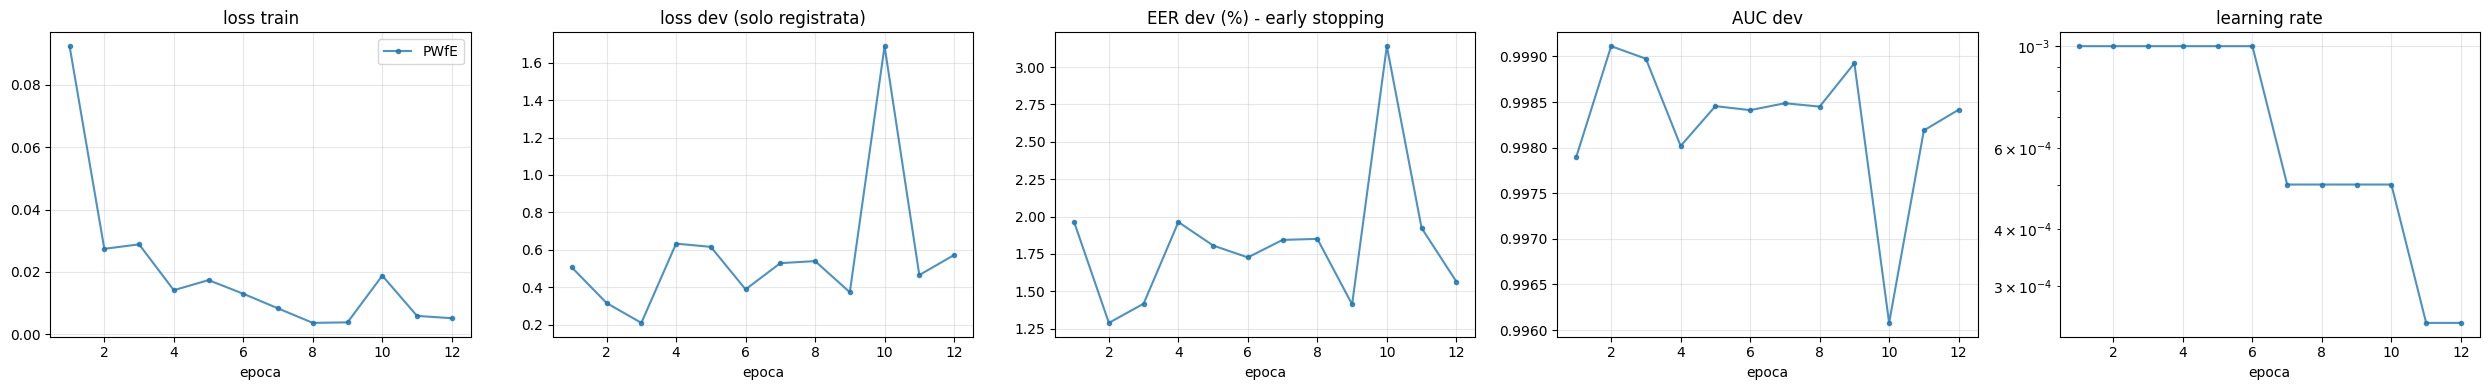

In [9]:

att_rows = []
for v in VARIANTS:
    r = {"variant": v}
    for a in sorted(set(ATTACK_DEV) - {"bonafide"}):
        m = (ATTACK_DEV == "bonafide") | (ATTACK_DEV == a)
        r[a] = round(100 * compute_eer(Y_DEV[m], avg[v][m]), 2)
    att_rows.append(r)
per_attack = pd.DataFrame(att_rows).set_index("variant")
display(per_attack)

def lead_zeros(x):
    nz = np.where(voiced_mask(x))[0]
    return nz[0] if len(nz) else len(x)

lead = np.array([lead_zeros(x) for x in BASE_DEV_SEQS])
diag = pd.DataFrame([{"variant": v,
                      "spearman_tutti": spearmanr(avg[v], lead)[0],
                      "spearman_spoof": spearmanr(avg[v][Y_DEV == 0], lead[Y_DEV == 0])[0],
                      "spearman_bona": spearmanr(avg[v][Y_DEV == 1], lead[Y_DEV == 1])[0]}
                     for v in VARIANTS]).set_index("variant").round(3)
print("Riferimento notebook 06, variante D: tutti 0,658 | spoof 0,659 | bona fide -0,070")
display(diag)

h = pd.read_csv(HIST)
fig, axes = plt.subplots(1, 5, figsize=(25, 4))
for (v, s), d in h.groupby(["variant", "seed"]):
    k = VARIANTS.index(v) if v in VARIANTS else 0
    kw = dict(color=f"C{k}", alpha=0.8, label=f"{v}" if s == SEEDS[0] else None, marker=".")
    axes[0].plot(d["epoch"], d["train_loss"], **kw)
    axes[1].plot(d["epoch"], d["dev_loss"], **kw)
    axes[2].plot(d["epoch"], 100 * d["dev_eer"], **kw)
    axes[3].plot(d["epoch"], d["dev_auc"], **kw)
    axes[4].plot(d["epoch"], d["lr"], **kw)
axes[4].set_yscale("log")
for ax, t in zip(axes, ["loss train", "loss dev (solo registrata)", "EER dev (%) - early stopping",
                        "AUC dev", "learning rate"]):
    ax.set_title(t); ax.set_xlabel("epoca"); ax.grid(alpha=0.3)
axes[0].legend()
plt.tight_layout(); plt.savefig(OUT_DIR / "curves.png", dpi=120); plt.show()

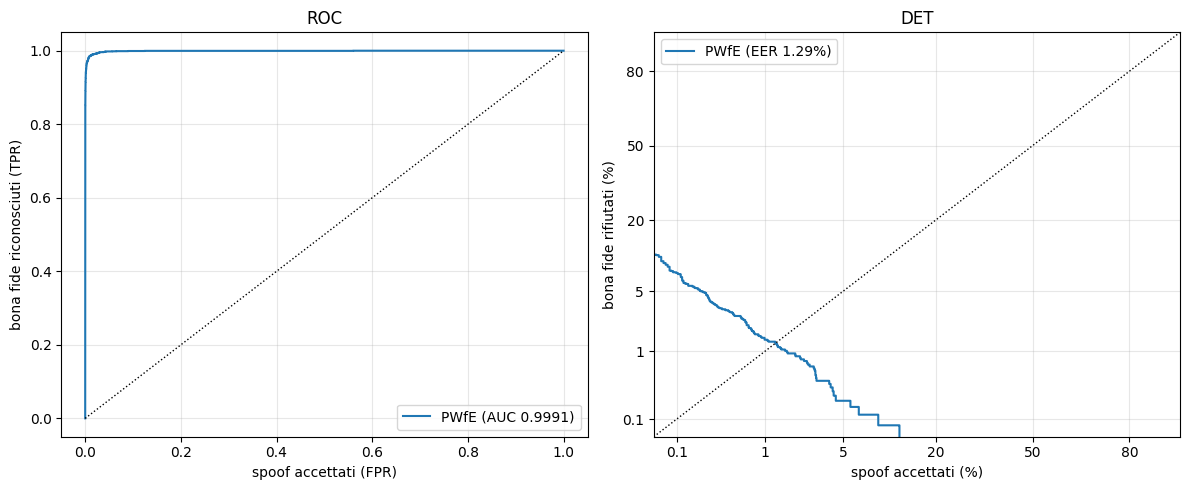

In [10]:
from scipy.stats import norm
_trapz = getattr(np, "trapezoid", None) or np.trapz

curves = {v: avg[v] for v in VARIANTS}
for name, path in EXTERNAL_SCORES.items():
    p = Path(path)
    if p.exists():
        s_ext = np.load(p)
        if len(s_ext) == len(Y_DEV):
            curves[name] = s_ext

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for k, (v, s_) in enumerate(curves.items()):
    s_ = np.asarray(s_, dtype=np.float64)
    frr, far, _ = asv_metrics.compute_det_curve(s_[Y_DEV == 1], s_[Y_DEV == 0])
    fpr, tpr = far[::-1], (1 - frr)[::-1]
    auc_off_curve = float(_trapz(tpr, fpr))
    auc_sk = roc_auc_score(Y_DEV, s_)
    assert abs(auc_off_curve - auc_sk) < 1e-3, (auc_off_curve, auc_sk)
    eer = compute_eer(Y_DEV, s_)
    axes[0].plot(fpr, tpr, color=f"C{k}", label=f"{v} (AUC {auc_sk:.4f})")
    fa, fr = np.clip(far, 1e-4, 1 - 1e-4), np.clip(frr, 1e-4, 1 - 1e-4)
    axes[1].plot(norm.ppf(fa), norm.ppf(fr), color=f"C{k}", label=f"{v} (EER {100 * eer:.2f}%)")
axes[0].plot([0, 1], [0, 1], "k:", lw=1)
axes[0].set_xlabel("spoof accettati (FPR)"); axes[0].set_ylabel("bona fide riconosciuti (TPR)"); axes[0].set_title("ROC")
ticks = np.array([0.001, 0.01, 0.05, 0.2, 0.5, 0.8])
for setter in (axes[1].set_xticks, axes[1].set_yticks):
    setter(norm.ppf(ticks))
axes[1].set_xticklabels([f"{100 * t:g}" for t in ticks]); axes[1].set_yticklabels([f"{100 * t:g}" for t in ticks])
lim = norm.ppf([0.0005, 0.9])
axes[1].plot(lim, lim, "k:", lw=1); axes[1].set_xlim(lim); axes[1].set_ylim(lim)
axes[1].set_xlabel("spoof accettati (%)"); axes[1].set_ylabel("bona fide rifiutati (%)"); axes[1].set_title("DET")
for ax in axes:
    ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.savefig(OUT_DIR / "roc_det.png", dpi=120); plt.show()

In [11]:

summary_out = {
    "variants": {v: "fusione tardiva end-to-end dei rami " + " + ".join(BRANCHES[v]) +
                    " (prosodia variante D sequenziale, Whisper livello di file 512, ECAPA livello di file 192); "
                    "embedding 50 per ramo, BatchNorm su ciascuno, concatenazione e MLP" for v in VARIANTS},
    "branches": BRANCHES,
    "feature_dirs": {"whisper_ecapa": {s: DATA[s]["dir"] for s in ["train", "dev"]},
                     "prosodia": str(PROSODY_ROOT)},
    "prosody": {"config": PROSODY_CONFIG, "variant": PROSODY_VARIANT, "window_s": meta_pros["window_s"],
                "features": feature_names(), "n_channels": int(D_PROSODY),
                "silence_rule": meta_pros["silence_rule"],
                "praat_version": meta_pros["praat_version"], "parselmouth_version": meta_pros["parselmouth_version"]},
    "preprocessing": {"prosodia": f"clipping ai percentili {CLIP_PCT} sui soli valori validi del train, "
                                  "poi Min-Max del train (identico al notebook 06)",
                      "whisper_file": "standardizzazione per dimensione di whisper_mean, statistiche sul train",
                      "whisper_frame": "non usato in questa esecuzione" if not NEED_FRAMES else
                                       "standardizzazione per dimensione, statistiche sui soli frame reali del train",
                      "ecapa": "standardizzazione per dimensione, statistiche sul train; nessuna normalizzazione L2",
                      "store_dtype": np.dtype(STORE_DTYPE).name},
    "eer_dev_%": summary.round(3).reset_index().to_dict("records"),
    "eer_per_seed_%": per_seed.round(3).reset_index().to_dict("records"),
    "comparisons": comparisons.round(4).to_dict("records"),
    "external_scores": {k: str(v) for k, v in EXTERNAL_SCORES.items()},
    "auc_dev": {v: float(roc_auc_score(Y_DEV, avg[v])) for v in VARIANTS},
    "auc_function": "sklearn.metrics.roc_auc_score (metrica non ASVspoof, complementare)",
    "eer_per_attack_%": per_attack.reset_index().to_dict("records"),
    "lead_silence_spearman": diag.reset_index().to_dict("records"),
    "lead_silence_reference_06_D": {"tutti": 0.658, "spoof": 0.659, "bona": -0.07},
    "training": {"mode": "end-to-end, tutti i rami addestrati insieme da inizializzazione casuale",
                 "max_epochs": MAX_EPOCHS, "patience": PATIENCE, "batch_size": BATCH_SIZE, "lr_initial": LR,
                 "lr_scheduler": {"type": "ReduceLROnPlateau (loss dev)", "factor": LR_FACTOR, "patience": LR_PATIENCE},
                 "dropout": DROPOUT, "pos_weight": POS_W, "seeds": SEEDS,
                 "early_stopping": "EER del dev (funzione ufficiale ASVspoof)",
                 "checkpoint": "EER dev minimo",
                 "scheduler_metric": "EER del dev",
                 "deviation_from_06_09": ("i notebook 06 e 09 usavano la loss BCE pesata sul dev per early "
                                          "stopping, scheduler e checkpoint. Nell'esecuzione del notebook 09 "
                                          "loss ed EER si muovevano in direzioni opposte (ramo E: loss da 0,79 "
                                          "a 4,10 in crescita monotona mentre l'EER scendeva fino all'epoca 6; "
                                          "fusione WE: checkpoint all'epoca 1 con EER 2,40% contro un minimo "
                                          "di 1,69% all'epoca 9). Il criterio e' stato quindi cambiato; le "
                                          "esecuzioni del notebook 09 vanno ripetute con lo stesso criterio "
                                          "prima di essere confrontate con questa"),
                 "device": DEVICE},
    "limits": ["early stopping, scheduler e checkpoint sono guidati direttamente dall'EER del dev, cioe' dalla "
               "stessa metrica riportata: e' il livello massimo di selezione sul dev e l'EER qui riportato e' un "
               "valore ottimizzato sul dev, non una stima delle prestazioni; la stima non distorta sara' quella "
               "su ASVspoof 2021 DF, con un solo modello scelto in anticipo",
               "un solo seme: nessuna stima della variabilita' di inizializzazione. Nel notebook 06 la variante D "
               "oscillava fra 9,93% e 11,77% di EER al variare del seme",
               "il bootstrap accoppiato misura l'incertezza di campionamento del dev, non quella di addestramento",
               "il confronto che isola il contributo della prosodia e' quello con WfE (stessi rami a livello di "
               "file, senza prosodia), non quello con WE (Whisper a livello di frame)"],
    "eer_function": {"source": EVAL_METRICS_URL, "sha256": EVAL_METRICS_SHA256}}
_ = (OUT_DIR / "summary.json").write_text(json.dumps(summary_out, indent=2, default=float))
print("Output:", sorted(p.name for p in OUT_DIR.iterdir() if p.is_file()))

Output: ['curves.png', 'eval_metrics.py', 'history.csv', 'model_PWfE_seed0.pt', 'preproc_prosody.json', 'results.csv', 'roc_det.png', 'scores_PWfE_seed0.npy', 'standardizer.json', 'summary.json']
